In [45]:
from strategy import *
from astropy.coordinates import ICRS
P = load_params('params_strategy.par')
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u

#The coordinates of the field
ra = 53.11667
dec = -27.80833
#load the observer position
lat = -77.83
location = EarthLocation(lat=lat*u.deg, lon=0*u.deg, height=0*u.m) 

# Define the fixed sky center
source = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')  # RA ≈ 3h32m = 3.5411h

decr = np.radians(dec)  # DEC offset due to scanning [rad]
latr = np.radians(lat)             # Observer latitude [rad]
# Hour angle [rad]

#Load the scan duration and generate the time coordinates with the desired acquisition rate. 
dt = 2.7777777777777e-06*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap.
T_duration = 1 #hours

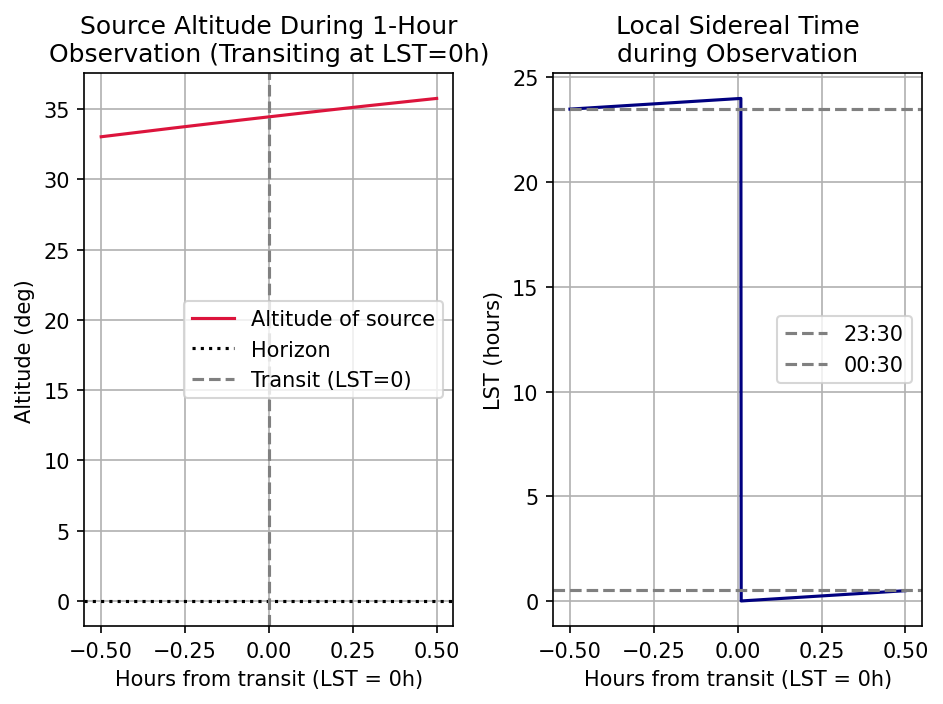

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Transit time (UTC): 2025-04-20 10:04:22.980 → LST = 00:00
LST at start: 23:29:17.82141501
LST at end  : 00:29:27.67807616


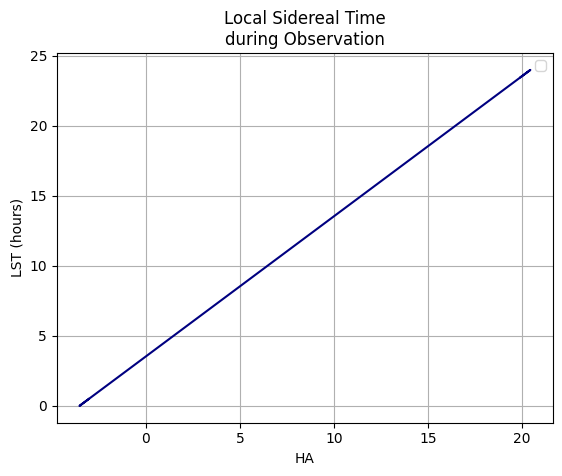

In [55]:
# So we find a time when LST = RA, and subtract RA to get LST=0h 
reference_time = Time("2025-04-20 00:00:00", scale="utc")
ra_hours = source.ra.to(u.hourangle).value  # ≈ 3.5411

# Find the UTC time when LST = RA
search_times = reference_time + np.linspace(0, 24, 10000) * u.hour
lst_array = search_times.sidereal_time('apparent', longitude=location.lon).hour
closest_idx = np.argmin(np.abs(lst_array - ra_hours))
time_zerolst = search_times[closest_idx]  # LST = RA

# Now shift back by RA hours → this puts LST = 0 at half the observing time
center_time = time_zerolst - ra_hours * u.hour  # LST=0 at source transit

# ---- Step 2: Create 1-hour observation window 
delta_hours = np.linspace(-T_duration/2, T_duration/2, 1000)
times = center_time + delta_hours * u.hour

# ---- Step 3: Compute AltAz and LST
altaz = source.transform_to(AltAz(obstime=times, location=location))
lst = times.sidereal_time('apparent', longitude=location.lon)

# ---- Plot Altitude vs Time ----
fig, axs = plt.subplots(1,2, dpi=150)
axs[0].plot(delta_hours, altaz.alt, label='Altitude of source', color='crimson')
axs[0].axhline(0, ls=':', color='black', label='Horizon')
axs[0].axvline(0, ls='--', color='gray', label='Transit (LST=0)')
axs[0].set_xlabel('Hours from transit (LST = 0h)')
axs[0].set_ylabel('Altitude (deg)')
#axs[0].set_ylim(32,37)
axs[0].set_title('Source Altitude During 1-Hour\nObservation (Transiting at LST=0h)')
axs[0].legend()
axs[0].grid(True)
# ---- Plot LST vs Time ----
axs[1].plot(delta_hours, lst.hour, color='navy')
axs[1].axhline(23.5, color='gray', linestyle='--', label='23:30')
axs[1].axhline(0.5, color='gray', linestyle='--', label='00:30')
axs[1].set_ylabel('LST (hours)')
axs[1].set_xlabel('Hours from transit (LST = 0h)')
axs[1].set_title('Local Sidereal Time\nduring Observation')
axs[1].grid(True)
axs[1].legend()
fig.tight_layout()
plt.show()

# ---- Print Transit Time and LST Range ----
print(f"Transit time (UTC): {center_time.iso} → LST = 00:00")
print(f"LST at start: {lst[0].to_string(unit=u.hour, sep=':', pad=True)}")
print(f"LST at end  : {lst[-1].to_string(unit=u.hour, sep=':', pad=True)}")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


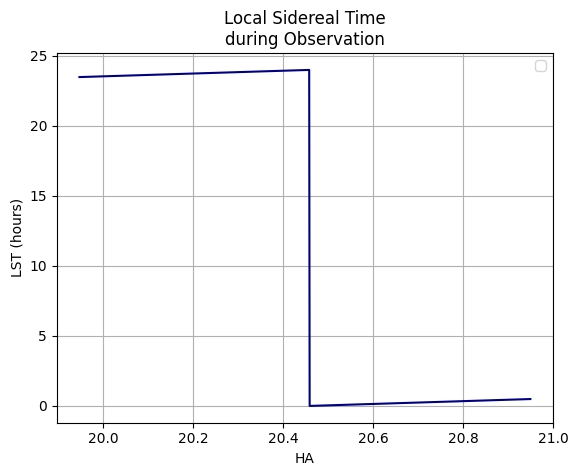

In [61]:
ra_hours = source.ra.to(u.hourangle).value  # Right Ascension in hours
# Calculate HA for each time
ha_hours = lst.hour - ra_hours  # LST - RA
ha_hours = (ha_hours + 24) % 24  # Ensures HA is between 0 and 24 hours

plt.plot(ha_hours, lst.hour, color='navy')
plt.ylabel('LST (hours)')
plt.xlabel('HA')
plt.title('Local Sidereal Time\nduring Observation')
plt.grid(True)
plt.legend()
fig.tight_layout()
